# Ablation — GPTQ + LQER: Full Quantization Pipeline

Evaluates the full advanced quantization pipeline against baseline and plain GPTQ.

| config | method | matrices | embeddings | LQER | group | asymmetric |
|---|---|---|---|---|---|---|
| Baseline | naive rounding | int8 per-row | fp16 passthrough | — | — | no |
| GPTQ int8 | GPTQ | int8 per-row | int8 per-row | — | — | no |
| GPTQ int6 | GPTQ | int6 per-row | int8 per-row | — | — | no |
| GPTQ+LQER | GPTQ | int6 group-32 | int7 per-row | rank-4 top-3 | 32 | yes |

## Goal

This notebook answers:
1. **Does the full GPTQ+LQER pipeline improve over plain GPTQ?** Comparing the round-trip BPB and quantization delta.
2. **How much does each component contribute?** Asymmetric group-wise quantization vs symmetric per-row, int7 embeddings vs int8, LQER correction vs no correction.
3. **What's the file size tradeoff?** LQER adds correction matrices; group-wise adds extra scales and zero-points. Is the BPB gain worth the storage cost?
4. **Which layers received LQER correction?** Identifying the most sensitive layers in the architecture.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib
import utils as utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

# Colors for each method
COLOR_BASELINE  = PALETTE[0]
COLOR_GPTQ      = PALETTE[1]
COLOR_GPTQ_LQER = PALETTE[2]

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\matte\_netrc.


## Original Baseline (3 seeds, reference)

In [2]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN  = df_base["final_val_bpb"].mean()
BASE_BPB_STD   = df_base["final_val_bpb"].std()
BASE_SIZE_MEAN = df_base["quant_file_bytes"].mean()

print("=" * 55)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 55)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"file size     : {BASE_SIZE_MEAN / 1e6:.2f} MB")
print("=" * 55)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311465        2.214354          15782427
  123       1.309002        2.210195          15785894
 1337       1.309833        2.211598          15776355

final_val_bpb : 1.3101 ± 0.0013
file size     : 15.78 MB


## Fetch All Ablation Runs

In [3]:
# --- Fetch plain GPTQ runs ---
GPTQ_PREFIX = "GPTQ_MATRICES"

gptq_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{GPTQ_PREFIX}"}},
))

gptq_rows = []
for run in gptq_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", cfg.get("quant_bits", 8))

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    gptq_rows.append({
        "run_name":         run.name,
        "method":           f"GPTQ int{bits}",
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
        "matrix_bits":      bits,
        "embed_bits":       cfg.get("embed_quant_bits", bits),
        "lqer_rank":        0,
        "lqer_top_k":       0,
        "group_size":       0,
        "asymmetric":       False,
    })

df_gptq = pd.DataFrame(gptq_rows)
print(f"Fetched {len(df_gptq)} plain GPTQ runs.")

Fetched 9 plain GPTQ runs.


In [4]:
df_gptq.head()

,run_name,method,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes,matrix_bits,embed_bits,lqer_rank,lqer_top_k,group_size,asymmetric
0,GPTQ_MATRICES_seed1337,GPTQ int6,1337,1.306296,1.364889,2.304558,11896932,6,6,0,0,0,False
1,GPTQ_MATRICES_seed42,GPTQ int6,42,1.308099,1.367217,2.308489,11897277,6,6,0,0,0,False
2,GPTQ_MATRICES_seed123,GPTQ int6,123,1.305630,1.362232,2.300072,11906305,6,6,0,0,0,False
3,GPTQ_MATRICES_seed1337,GPTQ int4,1337,1.306326,2.105418,3.554910,7850221,4,4,0,0,0,False
4,GPTQ_MATRICES_seed42,GPTQ int4,42,1.307331,2.203581,3.720654,7855540,4,4,0,0,0,False


In [5]:
# --- Fetch GPTQ+LQER runs ---
LQER_PREFIX = "GPTQ_LQER"

lqer_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{LQER_PREFIX}"}},
))

lqer_rows = []
for run in lqer_runs:
    s   = run.summary._json_dict
    cfg = run.config

    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    lqer_rows.append({
        "run_name":         run.name,
        "method":           "GPTQ+LQER",
        "seed":             cfg.get("seed"),
        "fp32_val_bpb":     fp32_bpb,
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
        "matrix_bits":      cfg.get("matrix_quant_bits", 6),
        "embed_bits":       cfg.get("embed_quant_bits", 7),
        "lqer_rank":        cfg.get("lqer_rank", 4),
        "lqer_top_k":       cfg.get("lqer_top_k", 3),
        "group_size":       cfg.get("quant_group_size", 32),
        "asymmetric":       bool(cfg.get("quant_asymmetric", 1)),
    })

df_lqer = pd.DataFrame(lqer_rows)
print(f"Fetched {len(df_lqer)} GPTQ+LQER runs.")

Fetched 19 GPTQ+LQER runs.


In [11]:
# --- Combine all runs ---
df_all = pd.concat([df_gptq, df_lqer], ignore_index=True)
df_all["delta_bpb"] = df_all["final_val_bpb"] - df_all["fp32_val_bpb"]

def std_or_zero(s):
    v = s.std(ddof=1)
    return 0.0 if pd.isna(v) else float(v)

# Aggregate per method configuration: mean ± std across seeds.
method_stats = (
    df_all.groupby(["method", "matrix_bits", "embed_bits", "lqer_rank", "lqer_top_k", "group_size", "asymmetric"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        final_val_bpb_mean=("final_val_bpb", "mean"),
        final_val_bpb_std=("final_val_bpb", std_or_zero),
        delta_bpb_mean=("delta_bpb", "mean"),
        delta_bpb_std=("delta_bpb", std_or_zero),
        quant_file_mb_mean=("quant_file_bytes", lambda x: x.mean() / 1e6),
        quant_file_mb_std=("quant_file_bytes", lambda x: std_or_zero(x) / 1e6),
    )
    .sort_values(["method", "matrix_bits", "embed_bits", "group_size", "lqer_rank", "lqer_top_k"])
    .reset_index(drop=True)
)

### Main comparison: Baseline vs GPTQ vs GPTQ+LQER

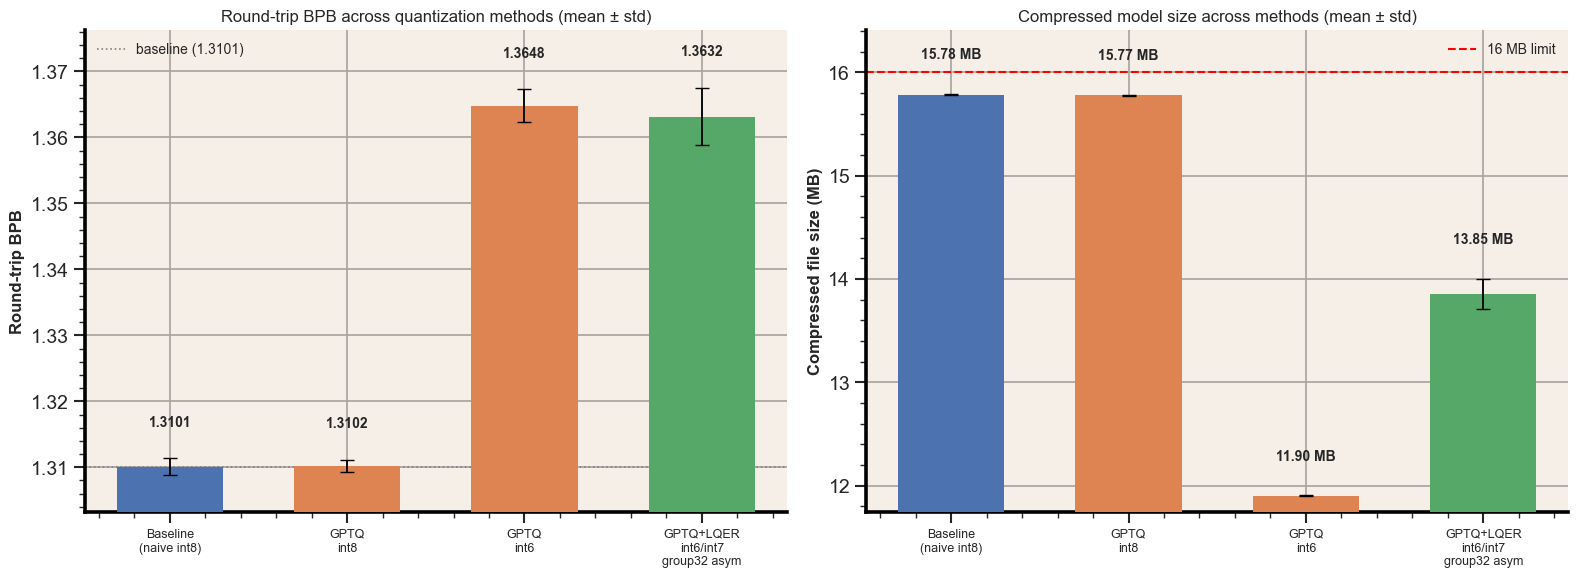

In [7]:
# Build comparison rows: baseline, GPTQ int8, GPTQ int6, GPTQ+LQER
comparison_methods = []
comparison_bpb = []
comparison_bpb_std = []
comparison_size = []
comparison_size_std = []
comparison_colors = []

# Baseline (3 seeds)
comparison_methods.append("Baseline\n(naive int8)")
comparison_bpb.append(BASE_BPB_MEAN)
comparison_bpb_std.append(0.0 if pd.isna(BASE_BPB_STD) else float(BASE_BPB_STD))
comparison_size.append(BASE_SIZE_MEAN / 1e6)
comparison_size_std.append(std_or_zero(df_base["quant_file_bytes"]) / 1e6)
comparison_colors.append(COLOR_BASELINE)

# GPTQ int8
gptq8 = method_stats[(method_stats["method"].str.startswith("GPTQ int")) & (method_stats["matrix_bits"] == 8)]
if not gptq8.empty:
    row = gptq8.iloc[0]
    comparison_methods.append("GPTQ\nint8")
    comparison_bpb.append(row["final_val_bpb_mean"])
    comparison_bpb_std.append(row["final_val_bpb_std"])
    comparison_size.append(row["quant_file_mb_mean"])
    comparison_size_std.append(row["quant_file_mb_std"])
    comparison_colors.append(COLOR_GPTQ)

# GPTQ int6
gptq6 = method_stats[(method_stats["method"].str.startswith("GPTQ int")) & (method_stats["matrix_bits"] == 6)]
if not gptq6.empty:
    row = gptq6.iloc[0]
    comparison_methods.append("GPTQ\nint6")
    comparison_bpb.append(row["final_val_bpb_mean"])
    comparison_bpb_std.append(row["final_val_bpb_std"])
    comparison_size.append(row["quant_file_mb_mean"])
    comparison_size_std.append(row["quant_file_mb_std"])
    comparison_colors.append(COLOR_GPTQ)

# GPTQ+LQER
lqer_stats = method_stats[method_stats["method"] == "GPTQ+LQER"]
if not lqer_stats.empty:
    row = lqer_stats.iloc[0]
    comparison_methods.append("GPTQ+LQER\nint6/int7\ngroup32 asym")
    comparison_bpb.append(row["final_val_bpb_mean"])
    comparison_bpb_std.append(row["final_val_bpb_std"])
    comparison_size.append(row["quant_file_mb_mean"])
    comparison_size_std.append(row["quant_file_mb_std"])
    comparison_colors.append(COLOR_GPTQ_LQER)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_methods))

# --- Round-trip BPB (mean ± std) ---
ax = axes[0]
ax.bar(x, comparison_bpb, color=comparison_colors, width=0.6, zorder=3)
ax.errorbar(
    x, comparison_bpb, yerr=comparison_bpb_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)

span_bpb = max(comparison_bpb) - min(comparison_bpb) if comparison_bpb else 0.0
pad_bpb = max(0.0002, 0.08 * span_bpb)
for i, bpb in enumerate(comparison_bpb):
    y = bpb + comparison_bpb_std[i] + pad_bpb
    ax.text(i, y, f"{bpb:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(x)
ax.set_xticklabels(comparison_methods, fontsize=9)
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("Round-trip BPB across quantization methods (mean ± std)", fontsize=12)
ax.legend(fontsize=10)

ymin_bpb = min([v - e for v, e in zip(comparison_bpb, comparison_bpb_std)], default=BASE_BPB_MEAN)
ymax_bpb = max([v + e for v, e in zip(comparison_bpb, comparison_bpb_std)], default=BASE_BPB_MEAN)
ax.set_ylim(ymin_bpb - pad_bpb * 1.3, ymax_bpb + pad_bpb * 2.0)

# --- Compressed file size (mean ± std) ---
ax = axes[1]
ax.bar(x, comparison_size, color=comparison_colors, width=0.6, zorder=3)
ax.errorbar(
    x, comparison_size, yerr=comparison_size_std, fmt="none",
    ecolor="black", elinewidth=1.3, capsize=5, zorder=4
)

span_size = max(comparison_size) - min(comparison_size) if comparison_size else 0.0
pad_size = max(0.02, 0.08 * span_size)
for i, mb in enumerate(comparison_size):
    y = mb + comparison_size_std[i] + pad_size
    ax.text(i, y, f"{mb:.2f} MB", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(16.0, color="red", linewidth=1.5, linestyle="--", label="16 MB limit")
ax.set_xticks(x)
ax.set_xticklabels(comparison_methods, fontsize=9)
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("Compressed model size across methods (mean ± std)", fontsize=12)
ax.legend(fontsize=10)

ymin_size = min([v - e for v, e in zip(comparison_size, comparison_size_std)], default=0.0)
ymax_size = max([v + e for v, e in zip(comparison_size, comparison_size_std)], default=0.0)
ax.set_ylim(ymin_size - pad_size * 0.5, ymax_size + pad_size * 2.0)

plt.tight_layout(pad=1.5)
plt.show()